In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/projectnb/batmanlab/mragoza/lung-project/notebooks/copdgene'

In [2]:
import sys, os

print(os.getpid())

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

def add_path(p: str):
    if p not in sys.path:
        sys.path.append(p)

add_path(os.environ['LP_ROOT'])
add_path(os.environ['PROJECT'])

import project
from project.core.utils import pprint

import torch
assert torch.cuda.is_available()

1504486


# Gather examples

In [3]:
from pathlib import Path
#data_root = Path(os.environ['LP_ROOT'] / 'data' / 'COPDGene'
data_root = Path(os.environ['PRIVATE']) / 'data' / 'COPDGene'
data_root.is_dir()

True

In [4]:
import pandas as pd
subject_file = data_root / 'sample1000_2025-07-22.csv'
subject_list = list(pd.read_csv(subject_file, sep='\t').sid)
len(subject_list)

1000

In [5]:
data_config = {
    'name': 'COPDGene',
    'root': str(data_root),
    'examples': {'subjects': subject_list}
}

In [6]:
examples = project.api.get_examples(data_config)
len(examples)

Gathering examples


2000

# View source images

In [7]:
import numpy as np

ex = examples[0]

def get_oriented_spacing(affine: np.ndarray):
    return tuple(float(d) for d in affine[:3,:3] @ np.ones(3))

src0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
src1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

src0_spacing = get_oriented_spacing(src0.affine)
src1_spacing = get_oriented_spacing(src1.affine)

print(src0_spacing)
print(src1_spacing)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
(-0.71875, 0.71875, 0.5)
(-0.71875, 0.71875, 0.7000007629394531)


In [8]:
import project.visual.matplotlib as mpl_viz
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

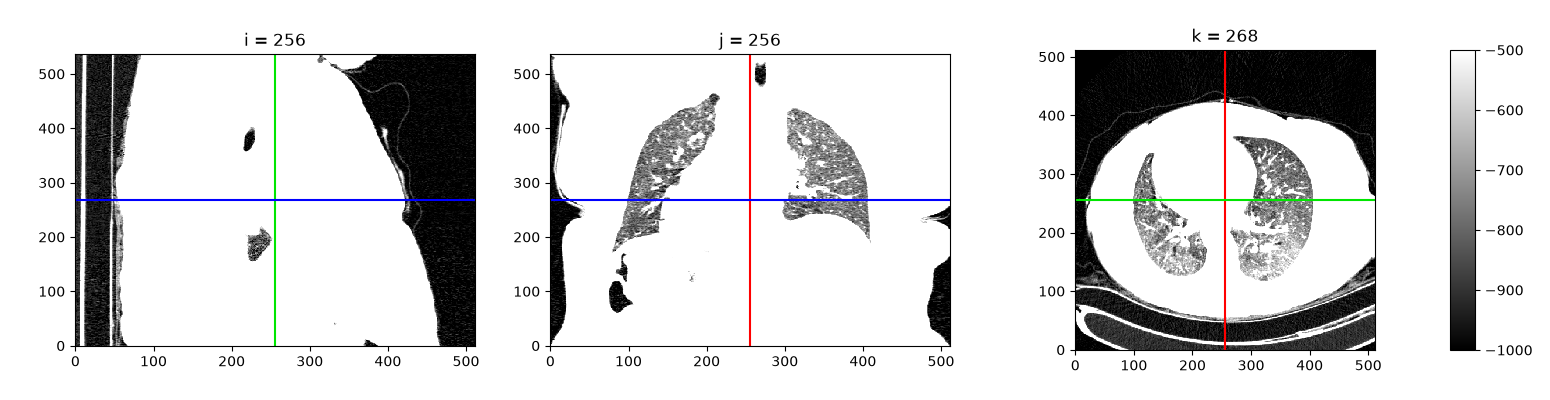

In [9]:
mpl_viz.SliceViewer(src0.get_fdata(), vox_spacing=src0_spacing, ax_height=3, ax_width=4, **img_kws)

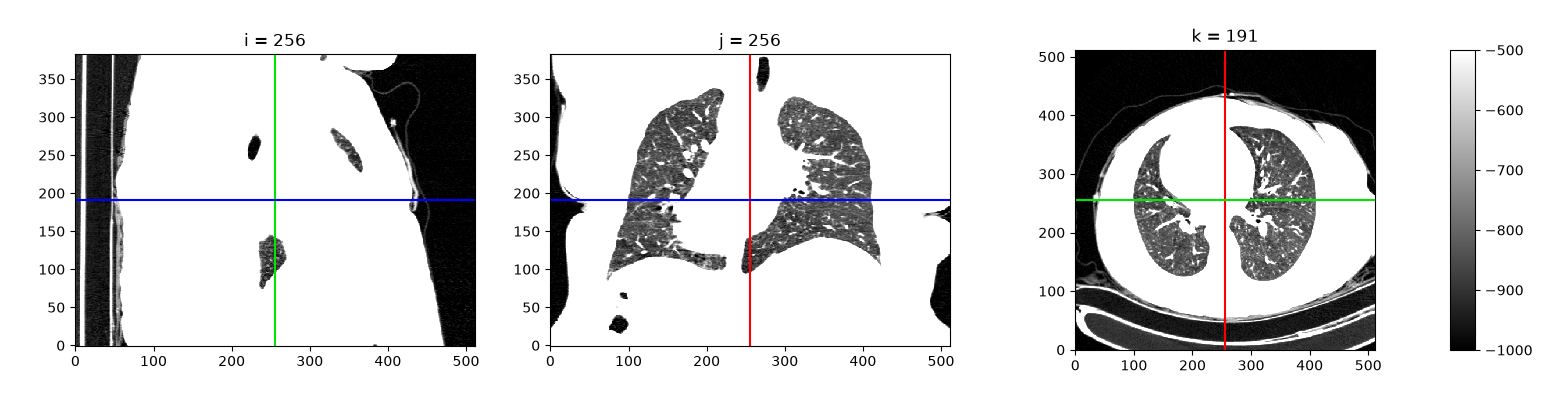

In [10]:
mpl_viz.SliceViewer(src1.get_fdata(), vox_spacing=src1_spacing, ax_height=3, ax_width=4, **img_kws)

# Preprocessing tests

In [11]:
# 2026-08-08 :: initial settings
data_config_v0 = { 
    'name': 'COPDGene',
    'root': str(data_root),
    'examples': {
        'subjects': subject_list,
        'variant': 'TEST',
        'pipeline_tags': {
            'image_segmentation':  'v0',
            'material_properties': 'v0',
            'mesh_generation':     'v0',
            'forward_simulation': 'stvk'
        }
    }
}

# 2026-08-18 :: after Bela meeting 1
data_config_v1 = { 
    'name': 'COPDGene',
    'root': str(data_root),
    'examples': {
        'subjects': subject_list,
        'variant': 'TEST',
        'pipeline_tags': {
            'image_segmentation':  'v1',
            'material_properties': 'v1',
            'mesh_generation':     'v1',
            'forward_simulation': 'neoh'
        }
    }
}

# 2026-08-25 :: after Bela meeting 2
# TODO

In [12]:
def estimate_circumradius(num_voxels, voxel_volume=1.0):
    total_volume = num_voxels * voxel_volume
    return 1.25 * total_volume ** (1 / 3)

[round(estimate_circumradius(n**3), 2) for n in [1, 2, 3, 4, 5]]

[1.25, 2.5, 3.75, 5.0, 6.25]

In [13]:
lung_roi_subset = [
    'lung_upper_lobe_right', 'lung_middle_lobe_right', 'lung_lower_lobe_right', 'lung_upper_lobe_left', 'lung_lower_lobe_left'
]
nnu_weights_dir = '/restricted/projectnb/batmanlab/haozhe/Lung_Mesh_Segment/data/nnUNetv2/nnUNet_results'
ugi_weights_dir = '/restricted/projectnb/batmanlab/mragoza/lung-project/network_weights'

proc_config = {
    'image_resampling': {
        'spacing': [1.0, 1.0, 1.0], 'interpolation': 'linear', 'default_value': -1000.
    },
    'image_segmentation': {
        'tasks': [
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'total', 'roi_subset': lung_roi_subset}
            },
            {
                'method': 'TotalSegmentator',
                'kwargs': {'task': 'lung_vessels'}
            },
            {
                'method': 'VisionFeature',
                'kwargs': {'model': 'vista3d', 'results_dir': nnu_weights_dir}
            },
            {
                'method': 'HU_threshold',
                'kwargs': {
                    #'sigma': 0.0, # v0
                    'sigma': 5.0, # v1
                    'thresholds': {
                        'lt-950': {'type': 'absolute', 'operator': '<', 'value': -950},
                        'lt-910': {'type': 'absolute', 'operator': '<', 'value': -910},
                        'lt-850': {'type': 'absolute', 'operator': '<', 'value': -850},
                        'gt-500': {'type': 'absolute', 'operator': '>', 'value': -500},
                        'gt-200': {'type': 'absolute', 'operator': '>', 'value': -200},
                    }
                }
            }
        ]
    },
    'image_registration': {
        'method': 'unigradicon',
        'kwargs': {
            'model': 'gradiconlung',
            'similarity': 'lncc2',
            'sigma': 1,
            'iterations': 50,
            'loss_function_masking': True,
            'intensity_conservation': True,
            'weights_root': ugi_weights_dir
        }
    },
    'anatomical_regions': {
        'roi_order': lung_roi_subset,
        'region_filter': {'min_voxels': 30, 'keep_largest': True}
    },
    'material_properties': {
        'density': {
            #'default': 1000., 'terms': {'image': {'weight': 1.0}, 'range': [1., 2000.]} # v0
            'default': 350., # v1
        },
        'youngs_modulus': {
            'default': 2000.,
            'terms': {
                #'lung_arteries': {'weight': +3000.}, # v0
                #'lung_veins':    {'weight': +3000.}, # v0
                #'lung_airways':  {'weight': +6000.}, # v0
                
                'lt-850':        {'weight': -1000.}, # v0,v1
                'lt-910':        {'weight':  -500.}, # v0,v1
                'lt-950':        {'weight':  -250.}, # v0,v1
                
                'ggo':           {'weight': +2000.}, # v0,v1
                'consolidation': {'weight': +4000.}, # v0,v1
                'nodule':        {'weight': +8000.}, # v0,v1
            },
            'range': [1., 20000.]
        },
        'poisson_ratio': {'default': 0.42}
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            #'max_cell_circumradius': 5.0, # v0
            'max_cell_circumradius': 3.75, # v1
            'max_facet_distance': 1.0,
            'lloyd': True, 'odt': True
        }
    },
    'mesh_interpolation': {
        'displacement_key': 'u_reg'
    },
    'forward_simulation': {
        'physics_adapter': {},
        'pde_solver': {
            '_class': 'warp',
            'material_type': 'neohookean',
            'g_vector': [0., -9.81, 0.],
            'scalar_degree': 1,
            'vector_degree': 1,
            'newton_steps': 100,
            'newton_tries': 32,
            'newton_alpha': 1.0,
            'newton_beta': 0.5,
            'newton_rtol': 1e-5,
            'cg_maxiter': 1000,
            'cg_rtol': 1e-4,
            'verbose': True
        },
        'boundary_condition': {'type': 'mesh_key', 'value': 'u_reg'},
        'output_key': 'u_fwd'
    }
}

In [14]:
%autoreload
import project.preprocessing

for ex in project.api.get_examples(data_config_v1)[:2]:
    project.preprocessing.api.preprocess_example(ex, proc_config)

print('Done')

Gathering examples
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v1_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_v1_domain.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v1_corr_INSP.nii.gz exists; Skipping stage estimate_displacement_field
INFO: /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v1_anat.nii.gz exists; Skipping stage label_anato

RuntimeError: Line search failed at Newton step 72

# Interactive visualization

In [ ]:
ex = project.api.get_examples(data_config_v1)[0]

In [ ]:
img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])

img0_spacing = get_oriented_spacing(img0.affine)
img1_spacing = get_oriented_spacing(img1.affine)
print(img0_spacing)
print(img1_spacing)

anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
mat = project.core.fileio.load_nibabel(ex.paths['material_map'])

emph = project.core.fileio.load_nibabel(ex.paths['init_state']['segment_dir'] / 'lt-850.nii.gz')

m = anat.get_fdata() > 0
print(m.sum(), 'voxels')

E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

mesh = project.core.fileio.load_meshio(ex.paths['target_mesh'])
mesh

In [ ]:
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

anat_kws = dict(cmap=mpl_viz.get_label_cmap(5, include_bg=True), vmin=0, vmax=5)
mask_kws = dict(cmap='binary', vmin=0, vmax=1)

rho_kws = dict(cmap='jet', vmin=0, vmax=1000)
nu_kws = dict(cmap='jet', vmin=0, vmax=0.5)
E_kws = dict(cmap='jet', vmin=0, vmax=2e4)

In [ ]:
mpl_viz.SliceViewer(img0.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **img_kws)

In [ ]:
mpl_viz.SliceViewer(img1.get_fdata() * m, vox_spacing=img1_spacing, ax_height=3, ax_width=4, **img_kws)

In [ ]:
mpl_viz.SliceViewer(anat.get_fdata(), vox_spacing=img0_spacing, ax_height=3, ax_width=4, **anat_kws)

In [ ]:
mpl_viz.SliceViewer((emph.get_fdata() + 1) / 2 * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **mask_kws)

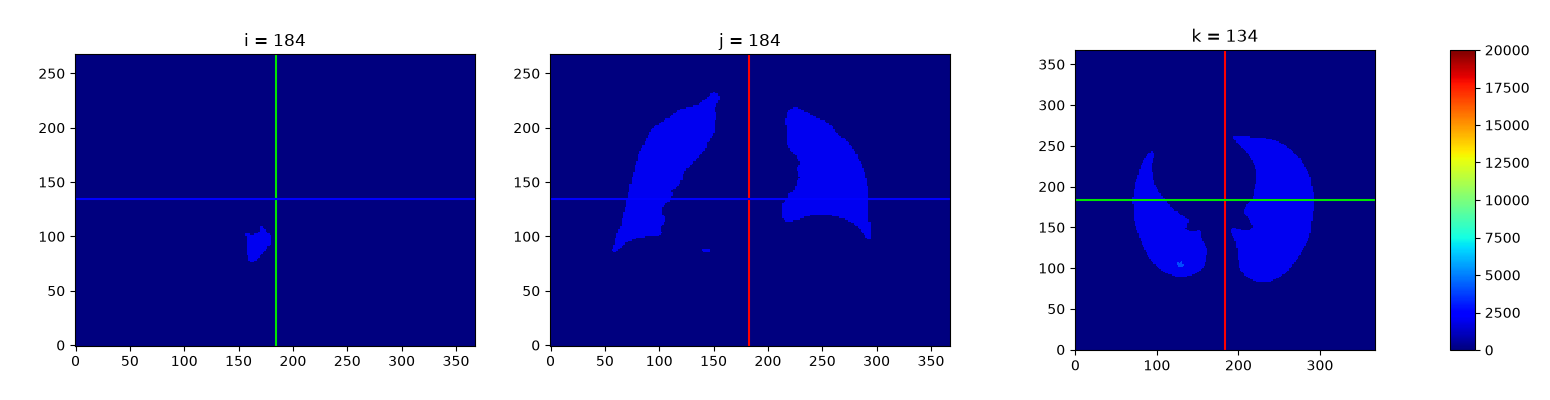

In [56]:
mpl_viz.SliceViewer(E.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **E_kws)

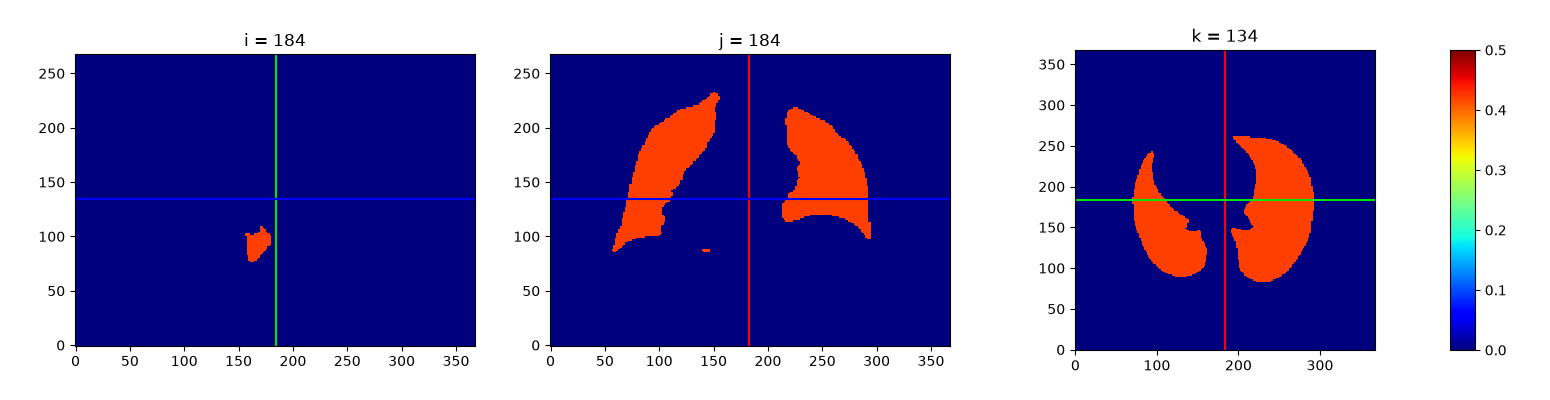

In [57]:
mpl_viz.SliceViewer(nu.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **nu_kws)

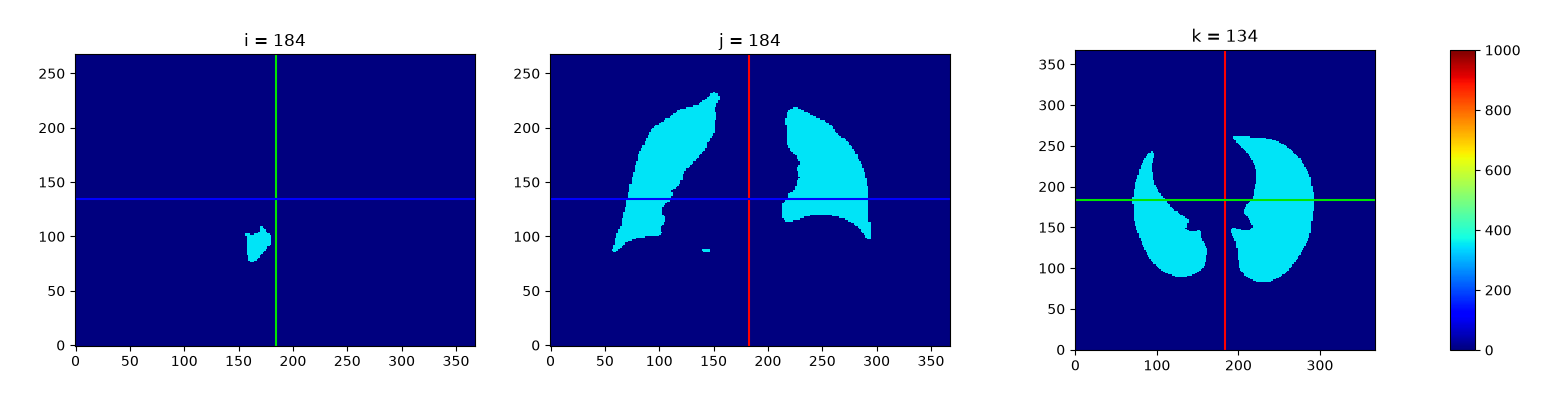

In [58]:
mpl_viz.SliceViewer(rho.get_fdata() * m, vox_spacing=img0_spacing, ax_height=3, ax_width=4, **rho_kws)

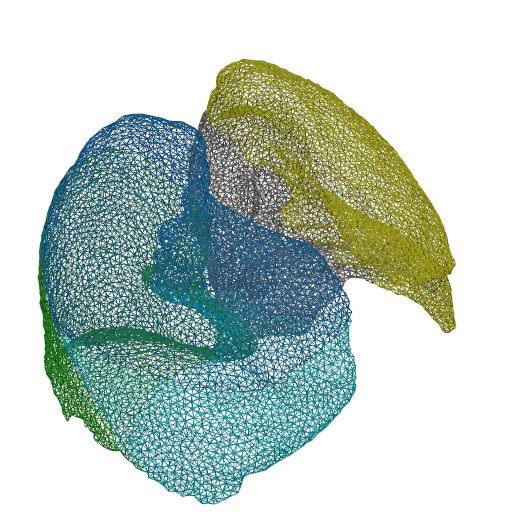

In [59]:
def show_mesh(mesh, window_size=(512,512), camera_zoom=4/3, **kwargs):
    import pyvista as pv
    p = pv.Plotter(window_size=window_size)
    p.add_mesh(pv.wrap(mesh), **kwargs)
    p.camera.zoom(camera_zoom)
    p.show(jupyter_backend='static')

show_mesh(
    mesh,
    style='wireframe',
    scalars='region',
    cmap=mpl_viz.get_label_cmap(5, include_bg=False),
    clim=(1, 5),
    show_scalar_bar=False
)

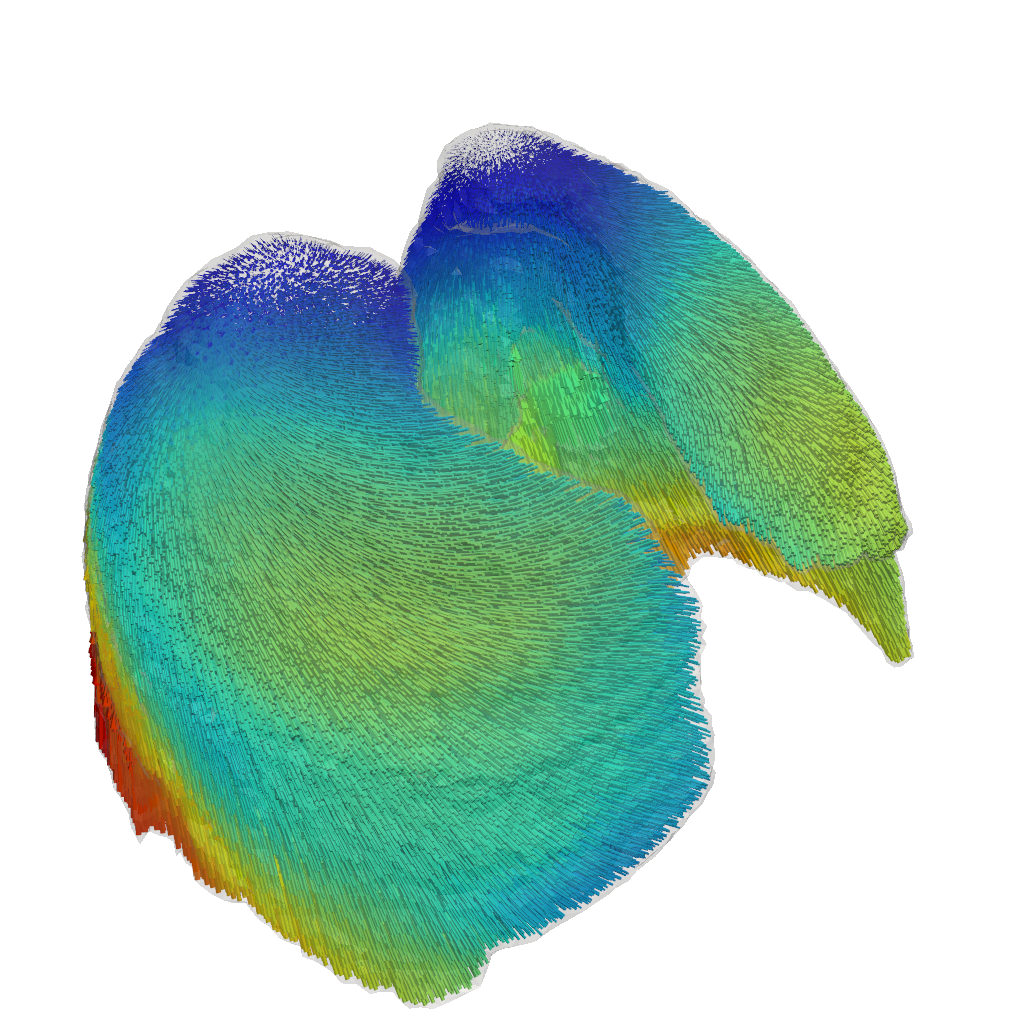

In [60]:
def show_disp(mesh, key, window_size=(512,512), camera_zoom=4/3):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=window_size)
    p.add_mesh(m, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, cmap='jet', show_scalar_bar=False)
    p.camera.zoom(camera_zoom)
    p.show(jupyter_backend='static')

    surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

show_disp(mesh, key='u_reg', window_size=(1024,1024))

# Optimization

In [100]:
import math

opt_config = {
    'targets': ['E'],
    'param_specs': {
        'E': {'mode': 'log10', 'mean': 3.0, 'std': 0.1}
    },
    'physics_adapter': {},
    'pde_solver': {
        '_class': 'warp',
        'material_type': 'linear',
        'g_vector': [0., -9.81, 0.],
        'relative_loss': True,
        'tv_reg_weight': 1e-4,
        'scalar_degree': 1,
        'vector_degree': 1,
        'newton_steps': 100,
        'newton_tries': 32,
        'newton_alpha': 1.0,
        'newton_beta': 0.5,
        'newton_rtol': 1e-4,
        'cg_maxiter': 1000,
        'cg_rtol': 1e-5,
        'verbose': True
    },
    'optimizer': {
        '_class': 'LBFGS',
        'lr': 1.0,
        'global_steps': 10,
        'local_steps': 100,
        'tol': 1e-3
    },
    'initialize': {
        'num_restarts': 1,
        'noise_std': 0.1
    },
    'boundary_condition': {
        'type': 'mesh_key',
        'value': 'u_reg'
    }
}

In [101]:
ex_v0 = project.api.get_examples(data_config_v0)[0]
ex_v1 = project.api.get_examples(data_config_v1)[0]

Gathering examples
Gathering examples


In [102]:
%autoreload
import project.optimization
project.optimization.simulate_example(ex_v0, opt_config)
project.optimization.simulate_example(ex_v1, opt_config)

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v0_corr_INSP_anat_v0_v0_int_stvk.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v0_label.nii.gz
Targets: ['E']
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA A40" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /usr2/collab/mragoza/.cache/warp/1.15.0
Module warp.fem.utils 21e5a09 load on device 'cuda:0' took 23.58 ms  (cached)
Module warp.fem.geometry.tetmesh 681bff0 load on device 'cuda:0' took 4.13 ms  (cached)
Module warp.fem.geometry.tetmesh 9b319f1 load on device 'cuda:0' took 3.98 ms  (cached)
Mod

In [103]:
outputs = {}
outputs['linear_v0'] = project.core.paths.RunOutputs(stage='opt_linear_v0')
outputs['linear_v1'] = project.core.paths.RunOutputs(stage='opt_linear_v1')

In [115]:
%autoreload
import project.optimization
project.optimization.optimize_example(ex_v0, opt_config, outputs['linear_v0'])
project.optimization.optimize_example(ex_v1, opt_config, outputs['linear_v1'])

Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v1_domain.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_v1_corr_INSP_anat_v1_v1_int_neoh.xdmf
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v1_v1_label.nii.gz
Targets: ['E']
Start optimization
Trial 1/1
Global optimization
Iteration 1 loss=2.4739e-03 (nan) grad=1.0647e-06 (1.0000e+00) norm=1.8957e+01 (nan)
Iteration 2 loss=2.4739e-03 (0.0000e+00) grad=1.0647e-06 (1.0000e+00) norm=1.8957e+01 (0.0000e+00)
Optimization converged
Local optimization
Iteration 1 loss=2.4769e-03 (nan) grad=2.6901e-05 (1.0000e+00) norm=1.8957e+01 (nan)
Iteration 2 loss=2.4769e-03 (0.0000e+00) grad=2.6901e-05 (1.0000e+00) norm=1.8957e+01 (0.0000e+00)
Optimization converged

In [118]:
pd.read_csv('metrics/example_metrics.csv.new.new.new.new.new.new.new.new.new.new.new').T

,0
epoch,0
phase,optimize
batch,0
step,0
loss,0.002477
subject,16514P
num_voxels,2144286
E_vox.mean,999.945749
E_vox.std,24.980473
E_vox.rms,1000.257729


In [110]:
import project.visual.matplotlib as mpl_viz

raster_dir = outputs['linear_v0'].raster_dir(ex_v0)
E_v0 = project.core.fileio.load_nibabel(raster_dir / 'E_pred.nii.gz').get_fdata()

Loading outputs/opt_linear_v0/16514P/rasters/E_pred.nii.gz


E_pred (v0)


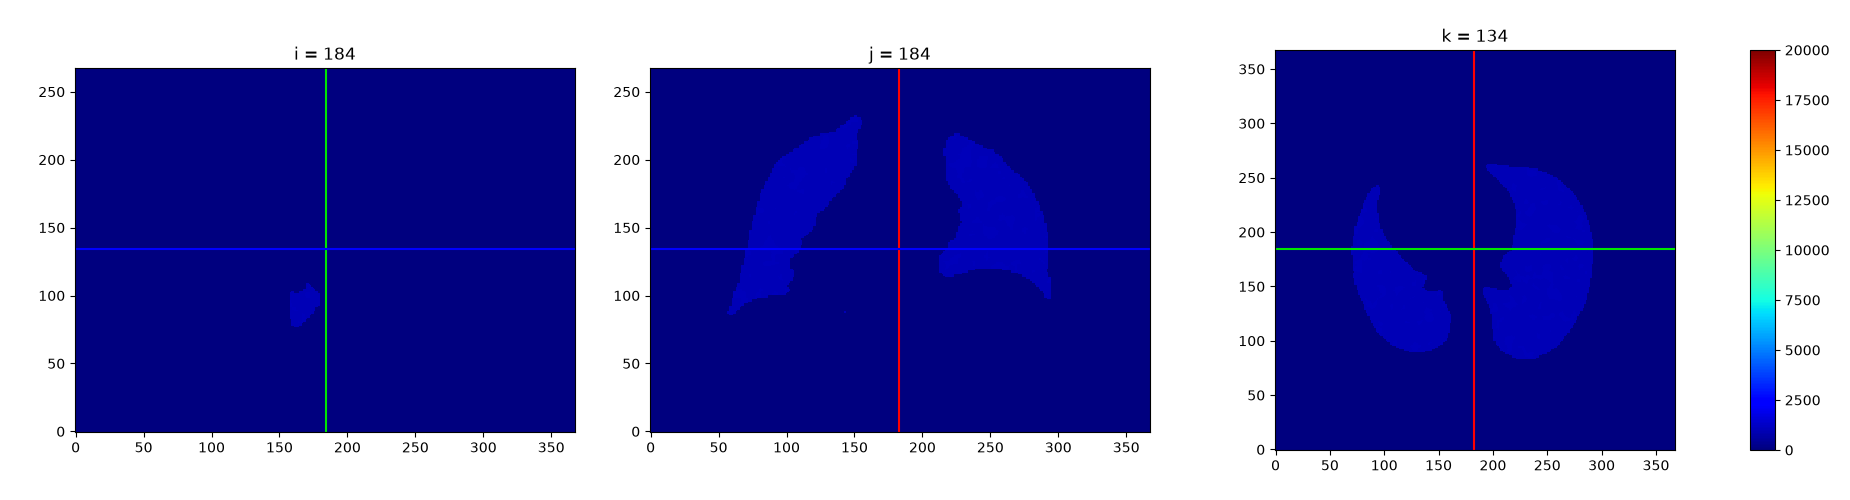

In [112]:
print('E_pred (v0)')
mpl_viz.SliceViewer(E_v0 * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

In [ ]:
print('E_pred (v1)')
mpl_viz.SliceViewer(E_v1 * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

E_true


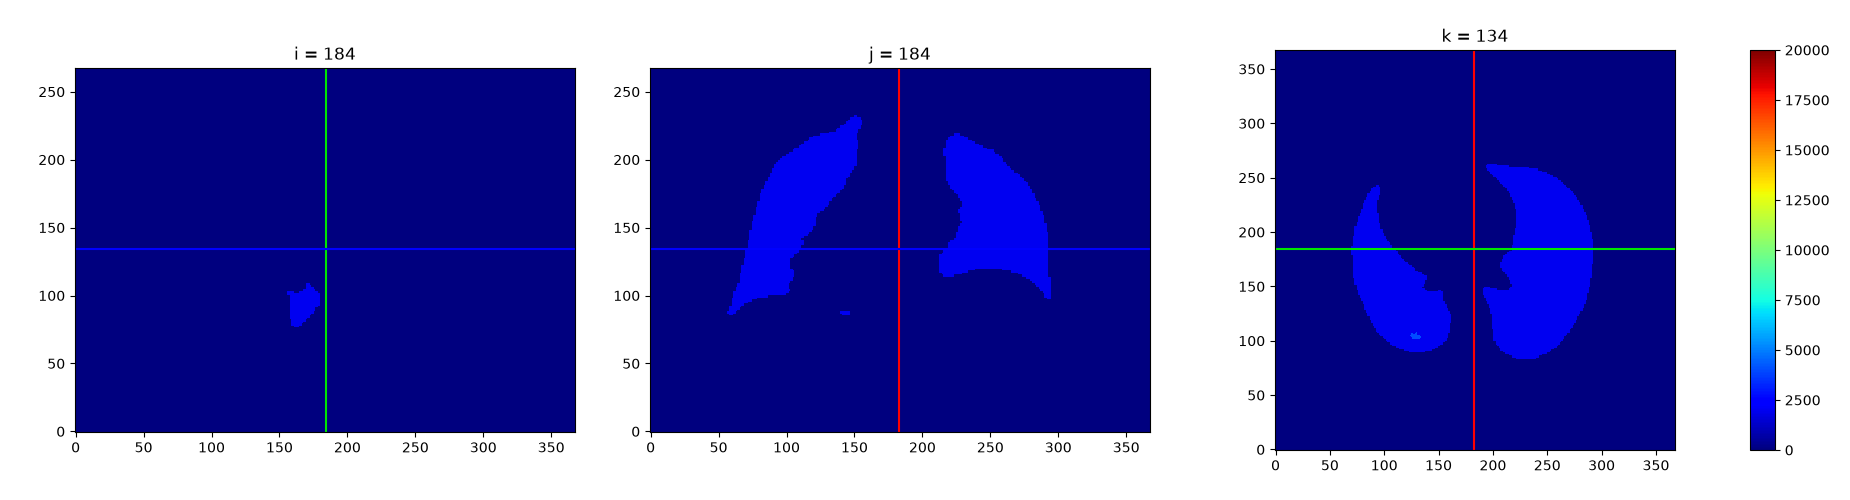

In [114]:
print('E_true')
mpl_viz.SliceViewer(E.get_fdata() * m, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='jet', clim=(0, 2e4))

nu - Linear


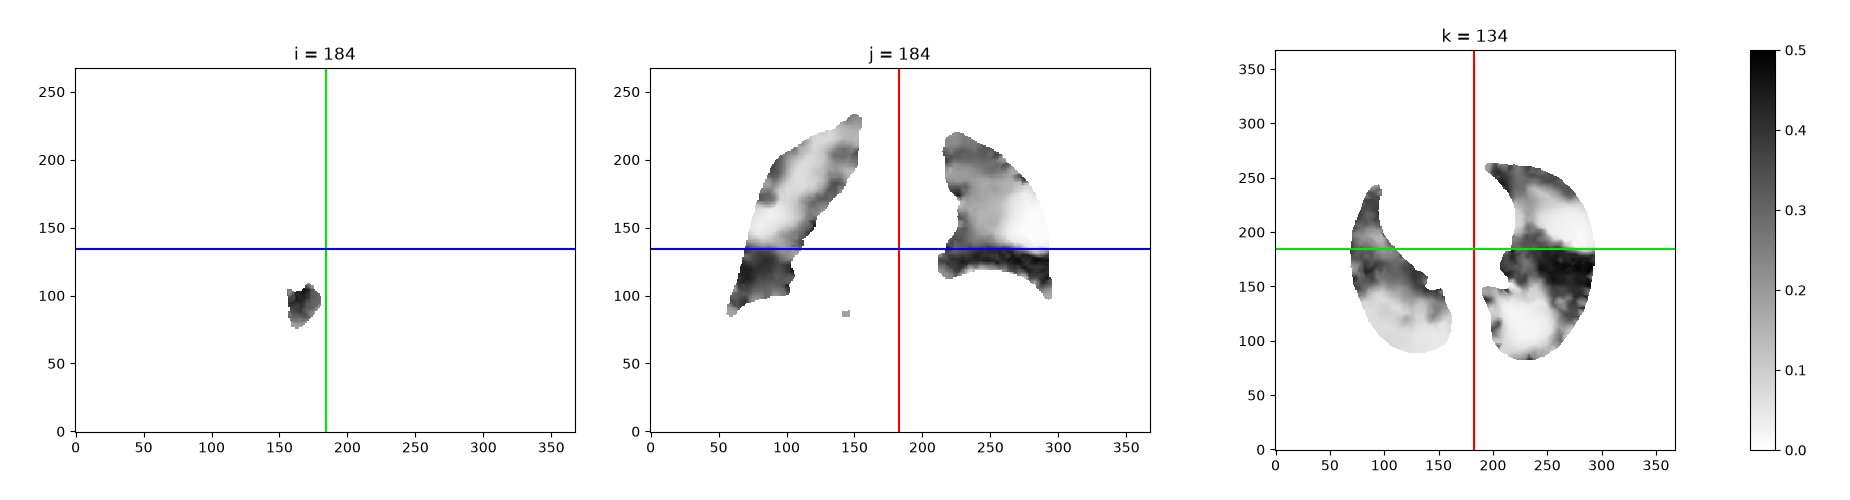

In [59]:
print('nu - Linear')
mpl_viz.SliceViewer(nu_lin, vox_spacing=spacing0, ax_height=4, ax_width=5, cmap='binary', clim=(0.0, 0.5))

# High-quality visualizations

In [120]:
ex = project.api.get_examples(data_config_v0)[0]

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
anat = project.core.fileio.load_nibabel(ex.paths['anatomical_map'])
m = anat.get_fdata() > 0

emph = project.core.fileio.load_nibabel(ex.paths['init_state']['segment_dir'] / 'lt-850.nii.gz')

E = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'youngs_modulus.nii.gz')
nu = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'poisson_ratio.nii.gz')
rho = project.core.fileio.load_nibabel(ex.paths['material_dir'] / 'density.nii.gz')

E_v0 = project.core.fileio.load_nibabel(outputs['linear_v0'].raster_dir(ex_v0) / 'E_pred.nii.gz')
E_v1 = project.core.fileio.load_nibabel(outputs['linear_v1'].raster_dir(ex_v1) / 'E_pred.nii.gz')

mesh = project.core.fileio.load_meshio(ex.paths['forward_mesh'])

Gathering examples
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0_anat.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_v0/lt-850.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v0/youngs_modulus.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v0/poisson_ratio.nii.gz
Loading /restricted/projectnb/batmanlab/mragoza/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_v0_v0/density.nii.gz
Loading outputs/opt_linear_v0/16514P/rasters/E_pred.nii.gz
Loading outputs/opt_linear_v1/16514P/rasters/E_pred.nii.gz


In [121]:
print(m.shape)
print(spacing0)
z = 120
c = 48

(368, 368, 268)
(-1.0, 1.0, 1.0)


In [122]:
img_kws = dict(cmap='gray', vmin=-1000, vmax=-500)

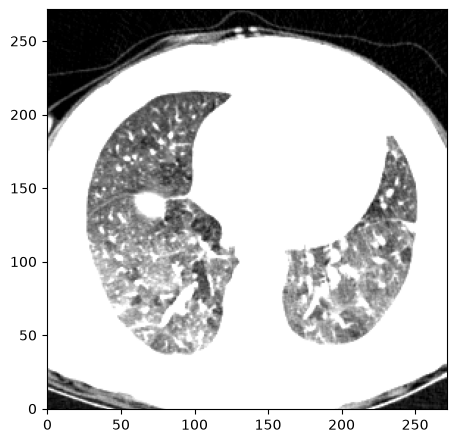

In [123]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

fig

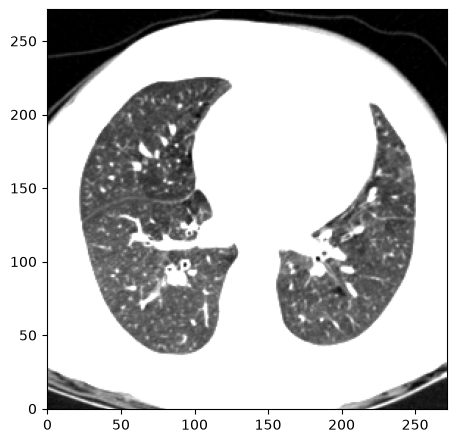

In [124]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)
fig

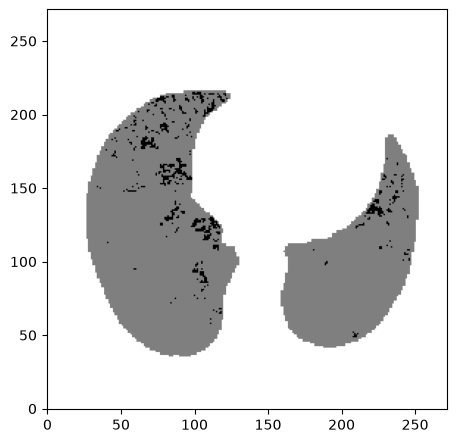

In [125]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(((emph.get_fdata() + 1)*m)[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 2))
fig

In [126]:
m = anat.get_fdata() > 0
E_m = E.get_fdata() * m
nu_m = nu.get_fdata() * m
rho_m = rho.get_fdata() * m

E_v0_m = E_v0.get_fdata() * m
E_v1_m = E_v1.get_fdata() * m

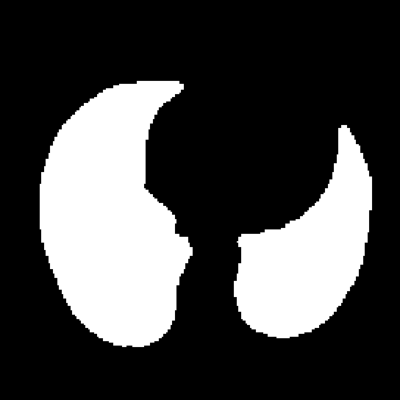

In [127]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(m[c:-c,c:-c,z].T, origin='lower', cmap='gray')

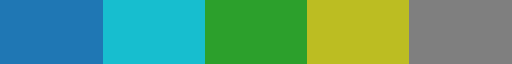

In [128]:
mpl_viz.get_label_cmap(5, include_bg=False)

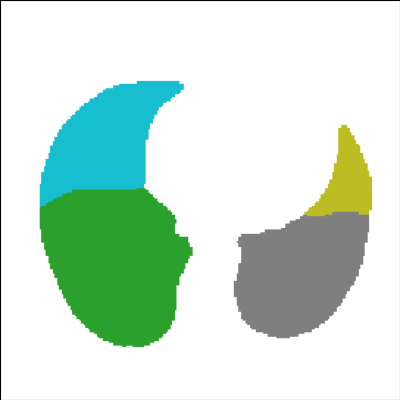

In [129]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow((anat.get_fdata())[c:-c,c:-c,z].T, origin='lower', cmap=mpl_viz.get_label_cmap(5, include_bg=True))

In [130]:
import matplotlib.pyplot as plt

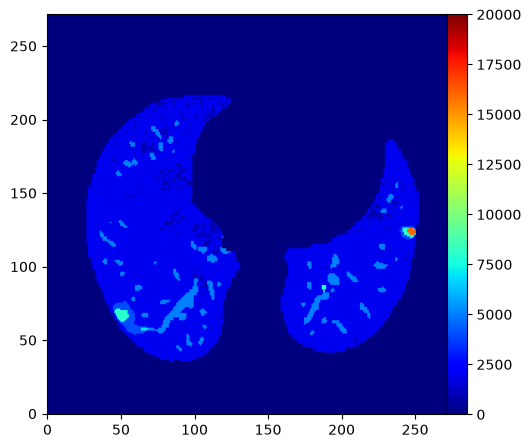

In [131]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_m[c:-c,c:-c,120].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

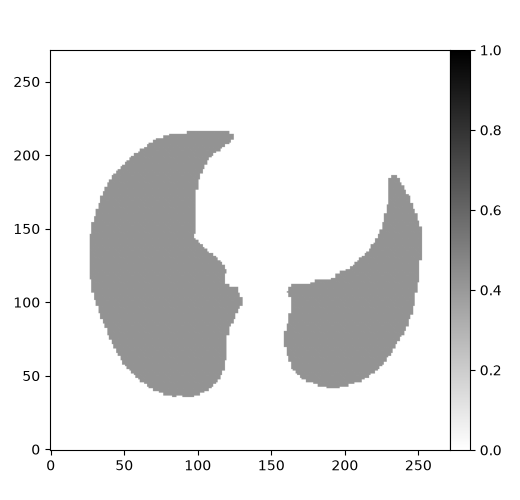

In [132]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(nu_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1))
plt.colorbar(im, cax)

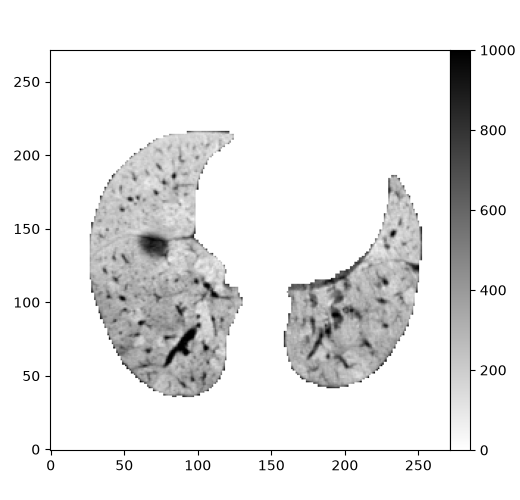

In [133]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(rho_m[c:-c,c:-c,z].T, origin='lower', cmap='binary', clim=(0, 1000))
plt.colorbar(im, cax)

In [138]:
np.mean(E_v0_m - E_v1_m)

np.float64(-0.020107227646429714)

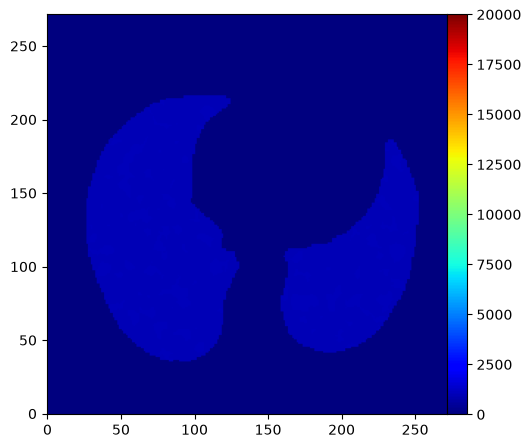

In [136]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_v0_m[c:-c,c:-c,z].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

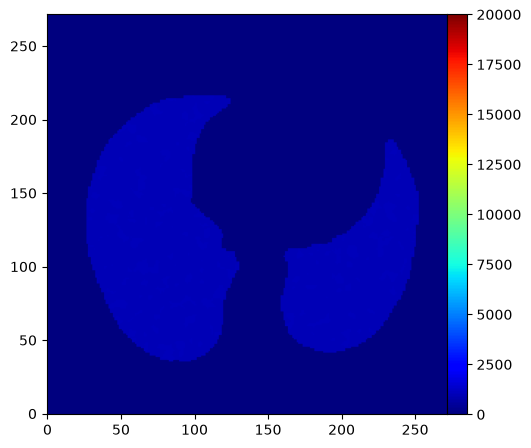

In [137]:
fig, ax, cax = mpl_viz.subplot_grid(1, 1, 4, 4, cbar_width=0.2, padding=0.5)

im = ax[0,0].imshow(E_v1_m[c:-c,c:-c,z].T, origin='lower', cmap='jet', clim=(0, 2e4))
plt.colorbar(im, cax)
fig

In [41]:
np.unique(mesh.cell_data['region'])

array([1, 2, 3, 4, 5])

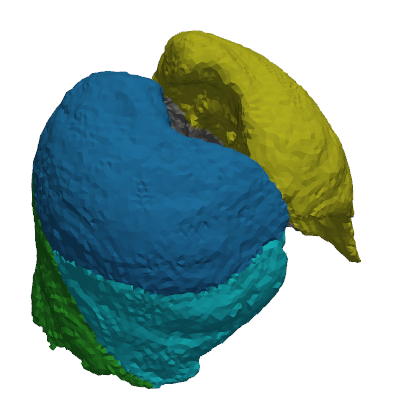

In [137]:
def show_mesh(mesh):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, scalars='region', show_scalar_bar=False, clim=(1, 5), opacity=1.0, cmap=mpl_viz.get_label_cmap(5, include_bg=False))
    #g = m.glyph(scale=key, orient=key, factor=1.0)
    #p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.4)
    p.show(jupyter_backend='static')

show_mesh(mesh)

In [158]:
vmax = np.percentile(np.linalg.norm(mesh.point_data['u_reg'], axis=1), 99)
vmax

np.float32(28.082287)

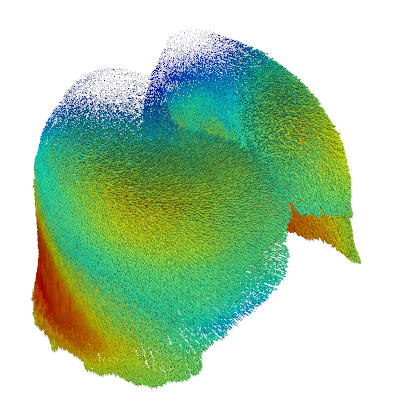

In [192]:
def plot_disp(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    #p.add_mesh(m, scalars=key, show_scalar_bar=False)
    g = m.glyph(scale=key, orient=key, factor=0.5)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet', clim=(0, vmax))
    p.camera.zoom(1.4)
    return p

p = plot_disp(mesh, key='u_reg')
p.show(jupyter_backend='static')

In [193]:
import pyvista as pv
surf = pv.wrap(mesh).extract_surface(algorithm='geometry')

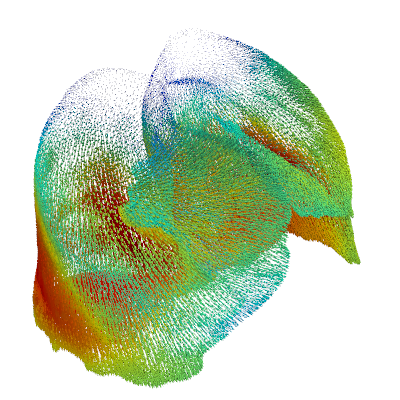

In [194]:
p = plot_disp(surf, key='u_reg')
p.show(jupyter_backend='static')

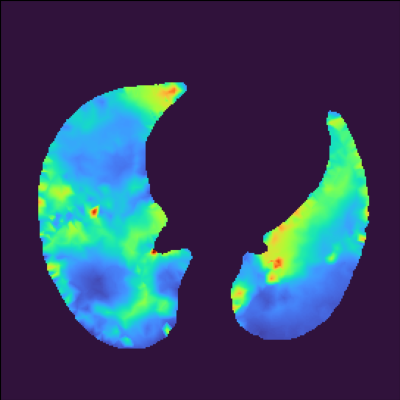

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

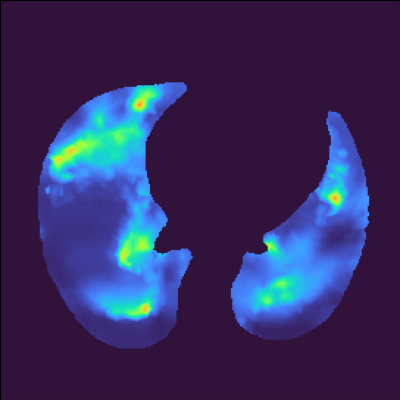

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

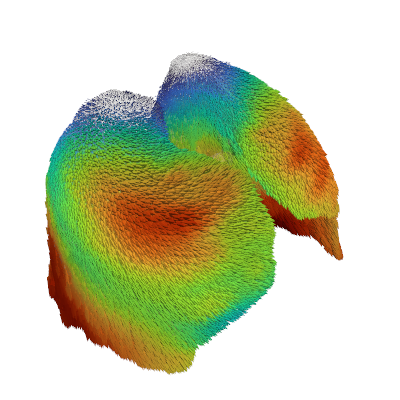

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

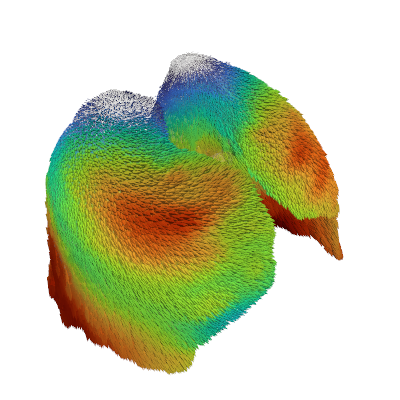

In [162]:
show_mesh(mesh, key='u_pred')

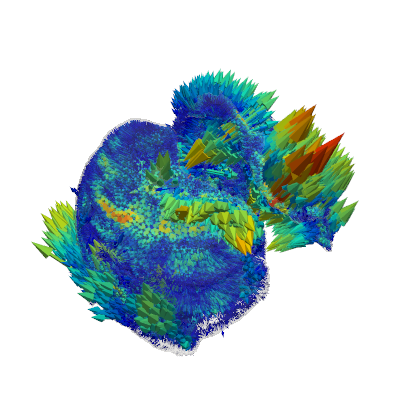

In [142]:
show_mesh(mesh, key='residual')